In [ ]:
!pip install pandas geopandas mapclassify

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Python for Geographic Data Analysis

# Extraindo os dados

Primeiro, vamos importar algumas camadas do geosampa. O link abaixo nos permite ver quais camadas estão disponíveis no GeoSampa via WFS.

https://wfs.geosampa.prefeitura.sp.gov.br/geoserver/geoportal/wfs?version=2.0.0&request=GetCapabilities

Abrindo esse link no navegador, temos uma saída como o trecho abaixo:

```{xml}
<wfs:WFS_Capabilities xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns="http://www.opengis.net/wfs/2.0" xmlns:wfs="http://www.opengis.net/wfs/2.0" xmlns:ows="http://www.opengis.net/ows/1.1" xmlns:gml="http://www.opengis.net/gml/3.2" xmlns:fes="http://www.opengis.net/fes/2.0" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:xs="http://www.w3.org/2001/XMLSchema" xmlns:geoportal="http://geoportal.prodam" version="2.0.0" xsi:schemaLocation="http://www.opengis.net/wfs/2.0 http://wfs.geosampa.prefeitura.sp.gov.br/geoserver/schemas/wfs/2.0/wfs.xsd" updateSequence="3005">
  <ows:ServiceIdentification>
    <ows:Title>Web Feature Service</ows:Title>
    <ows:Abstract>Servidor WFS corporativo.</ows:Abstract>
    <ows:Keywords>
      <ows:Keyword>WFS</ows:Keyword>
      <ows:Keyword>WMS</ows:Keyword>
    </ows:Keywords>
    <ows:ServiceType>WFS</ows:ServiceType>
    <ows:ServiceTypeVersion>2.0.0</ows:ServiceTypeVersion>
    <ows:Fees>NONE</ows:Fees>
    <ows:AccessConstraints>NONE</ows:AccessConstraints>
  </ows:ServiceIdentification>
  <ows:ServiceProvider>
    <ows:ProviderName>Prodam</ows:ProviderName>
    <ows:ServiceContact>
      <ows:IndividualName>Nucleo de Geoprocessamento</ows:IndividualName>
      <ows:PositionName/>
      <ows:ContactInfo>
        <ows:Phone>
          <ows:Voice/>
          <ows:Facsimile/>
        </ows:Phone>
        <ows:Address>
          <ows:DeliveryPoint/>
          <ows:City/>
          <ows:AdministrativeArea/>
          <ows:PostalCode/>
          <ows:Country/>
          <ows:ElectronicMailAddress>prodam@prodam.sp.gov.br</ows:ElectronicMailAddress>
        </ows:Address>
      </ows:ContactInfo>
    </ows:ServiceContact>
  </ows:ServiceProvider>
```
...

```{xml}
  <FeatureTypeList>
    <FeatureType xmlns:geoportal="http://geoportal.prodam">
      <Name>geoportal:adesampa</Name>
      <Title>ADESampa</Title>
      <Abstract>Espaço compartilhado de trabalho e de atendimento ao empreendedor.</Abstract>
      <ows:Keywords>
        <ows:Keyword>features</ows:Keyword>
        <ows:Keyword>adesampa</ows:Keyword>
      </ows:Keywords>
      <DefaultCRS>urn:ogc:def:crs:EPSG::31983</DefaultCRS>
      <ows:WGS84BoundingBox>
        <ows:LowerCorner>-47.47849807885537 -24.19376329804249</ows:LowerCorner>
        <ows:UpperCorner>-45.773692681083574 -23.137814287792693</ows:UpperCorner>
      </ows:WGS84BoundingBox>
    </FeatureType>
    <FeatureType xmlns:geoportal="http://geoportal.prodam">
      <Name>geoportal:GEOSAMPA_zoneamento_geoambiental_apa_borore</Name>
      <Title>APA Bororé-Colônia - Zoneamento Geoambiental</Title>
      <Abstract>APA Bororé-Colônia - Zoneamento Geoambiental</Abstract>
      <ows:Keywords>
        <ows:Keyword>features</ows:Keyword>
        <ows:Keyword>zoneamento_geoambiental_apa_borore</ows:Keyword>
      </ows:Keywords>
      <DefaultCRS>urn:ogc:def:crs:EPSG::31983</DefaultCRS>
      <ows:WGS84BoundingBox>
        <ows:LowerCorner>-46.740145195068315 -23.868003742626026</ows:LowerCorner>
        <ows:UpperCorner>-46.62103114967857 -23.7542934769047</ows:UpperCorner>
      </ows:WGS84BoundingBox>
    </FeatureType>
```

## Construindo as *URLs* com variáveis

Agora que sabemos o que podemos consultar, vamos nos preparar para formular as consultas.

In [ ]:
BASE_URL = 'https://wfs.geosampa.prefeitura.sp.gov.br/geoserver/geoportal/wfs?version=2.0.0'
GET_FEATURE_PARAM = 'request=GetFeature'
FEATURE_TYPE_PARAM = 'typename='
OUTPUT_FORMAT_PARAM = 'outputFormat=application/json'


Então, utilizamos as variáveis anteriores para construir a URL de acesso aos dados.

In [ ]:
distrito_url = BASE_URL + '&' + GET_FEATURE_PARAM + '&' + FEATURE_TYPE_PARAM + 'distrito_municipal' + '&' + OUTPUT_FORMAT_PARAM
distrito_url

In [ ]:
distritos_gdf = gpd.read_file(distrito_url)
distritos_gdf

In [ ]:
area_inund_url = BASE_URL + '&' + GET_FEATURE_PARAM + '&' + FEATURE_TYPE_PARAM + 'area_inundavel' + '&' + OUTPUT_FORMAT_PARAM
area_inund_url

In [ ]:
area_inund_gdf = gpd.read_file(area_inund_url)
area_inund_gdf

In [ ]:
cortico_url = BASE_URL + '&' + GET_FEATURE_PARAM + '&' + FEATURE_TYPE_PARAM + 'habita2geosampa_habi_cortico2geosampa' + '&' + OUTPUT_FORMAT_PARAM
cortico_url

In [ ]:
cortico_gdf = gpd.read_file(cortico_url)
cortico_gdf

Vamos pegar também os equipamentos culturais. Porém, eles estão separados categoricamente em camadas diferentes.

In [ ]:
esp_culturais_url = BASE_URL + '&' + GET_FEATURE_PARAM + '&' + FEATURE_TYPE_PARAM + 'equipamento_cultura_espacos_culturais' + '&' + OUTPUT_FORMAT_PARAM
esp_culturais_url

In [ ]:
esp_culturais_gdf = gpd.read_file(esp_culturais_url)
esp_culturais_gdf

In [ ]:
museus_url = BASE_URL + '&' + GET_FEATURE_PARAM + '&' + FEATURE_TYPE_PARAM + 'equipamento_cultura_museus' + '&' + OUTPUT_FORMAT_PARAM
museus_url

In [ ]:
museus_gdf = gpd.read_file(museus_url)
museus_gdf

Vamos conferir se as colunas são as mesmas entre as duas tabelas de equipamentos culturais.

In [ ]:
esp_culturais_gdf.columns

In [ ]:
museus_gdf.columns

## Comparando colunas com *for*

Como são muitas colunas, vamos usar uma combinação de `for` e `if` para verificar se existem diferenças.

In [ ]:
# Primeiro, vamos ver se alguma coluna de esp_culturais_gdf não está presente
# nas colunas de museus_gdf

col_faltante = False
for col in esp_culturais_gdf.columns:
    if col not in museus_gdf.columns:
        col_faltante = True
        print('A coluna ' + col + 'não existe em museus_gdf!')

if not col_faltante:
    print('Todas as colunas de esp_culturais_gdf estão em museus_gdf!')

In [ ]:
# Agora, fazemos o inverso. Vamos ver se alguma coluna de museus_gdf não está
# presente nas colunas de esp_culturais_gdf

col_faltante = False
for col in museus_gdf.columns:
    if col not in esp_culturais_gdf:
        col_faltante = True
        print('A coluna ' + col + 'não existe em esp_culturais_gdf!')

if not col_faltante:
    print('Todas as colunas de museus_gdf estão em esp_culturais_gdf!')

Se todas as colunas de uma tabela estão presentes na outra e vice-versa, as colunas das duas tabelas são iguais. Além disso, as colunas `nm_tipo_equipamento` e `tx_tipo_equipamento` parecem existir para, justamente, diferenciar as categorias de equipamentos. Portanto, vamos automatizar o download das 5 categorias de equipamentos e concatená-las em uma tabela.

In [ ]:
feature_types_cultura = ['equipamento_cultura_bibliotecas',
                         'equipamento_cultura_outros',
                         'equipamento_cultura_museus',
                         'equipamento_cultura_espacos_culturais',
                         'equipamento_cultura_teatro_cinema_show',]

## Obtendo tabelas com *for*

In [ ]:
gdfs_cultura = []
for ftype in feature_types_cultura:
    url = BASE_URL + '&' + GET_FEATURE_PARAM + '&' + FEATURE_TYPE_PARAM + ftype + '&' + OUTPUT_FORMAT_PARAM
    gdf = gpd.read_file(url)
    gdfs_cultura.append(gdf)
gdfs_cultura[0]

In [ ]:
gdfs_cultura[1]

## Concatenando ("empilhando") tabelas

In [ ]:
equip_cultura_gdf = pd.concat(gdfs_cultura)
equip_cultura_gdf = gpd.GeoDataFrame(equip_cultura_gdf)
equip_cultura_gdf.set_crs(gdfs_cultura[0].crs, inplace=True)
equip_cultura_gdf

In [ ]:
equip_cultura_gdf.reset_index(drop=True,inplace=True)
equip_cultura_gdf

# Agregando informações

De maneira resumida, duas geometrias podem ter as seguintes relações:

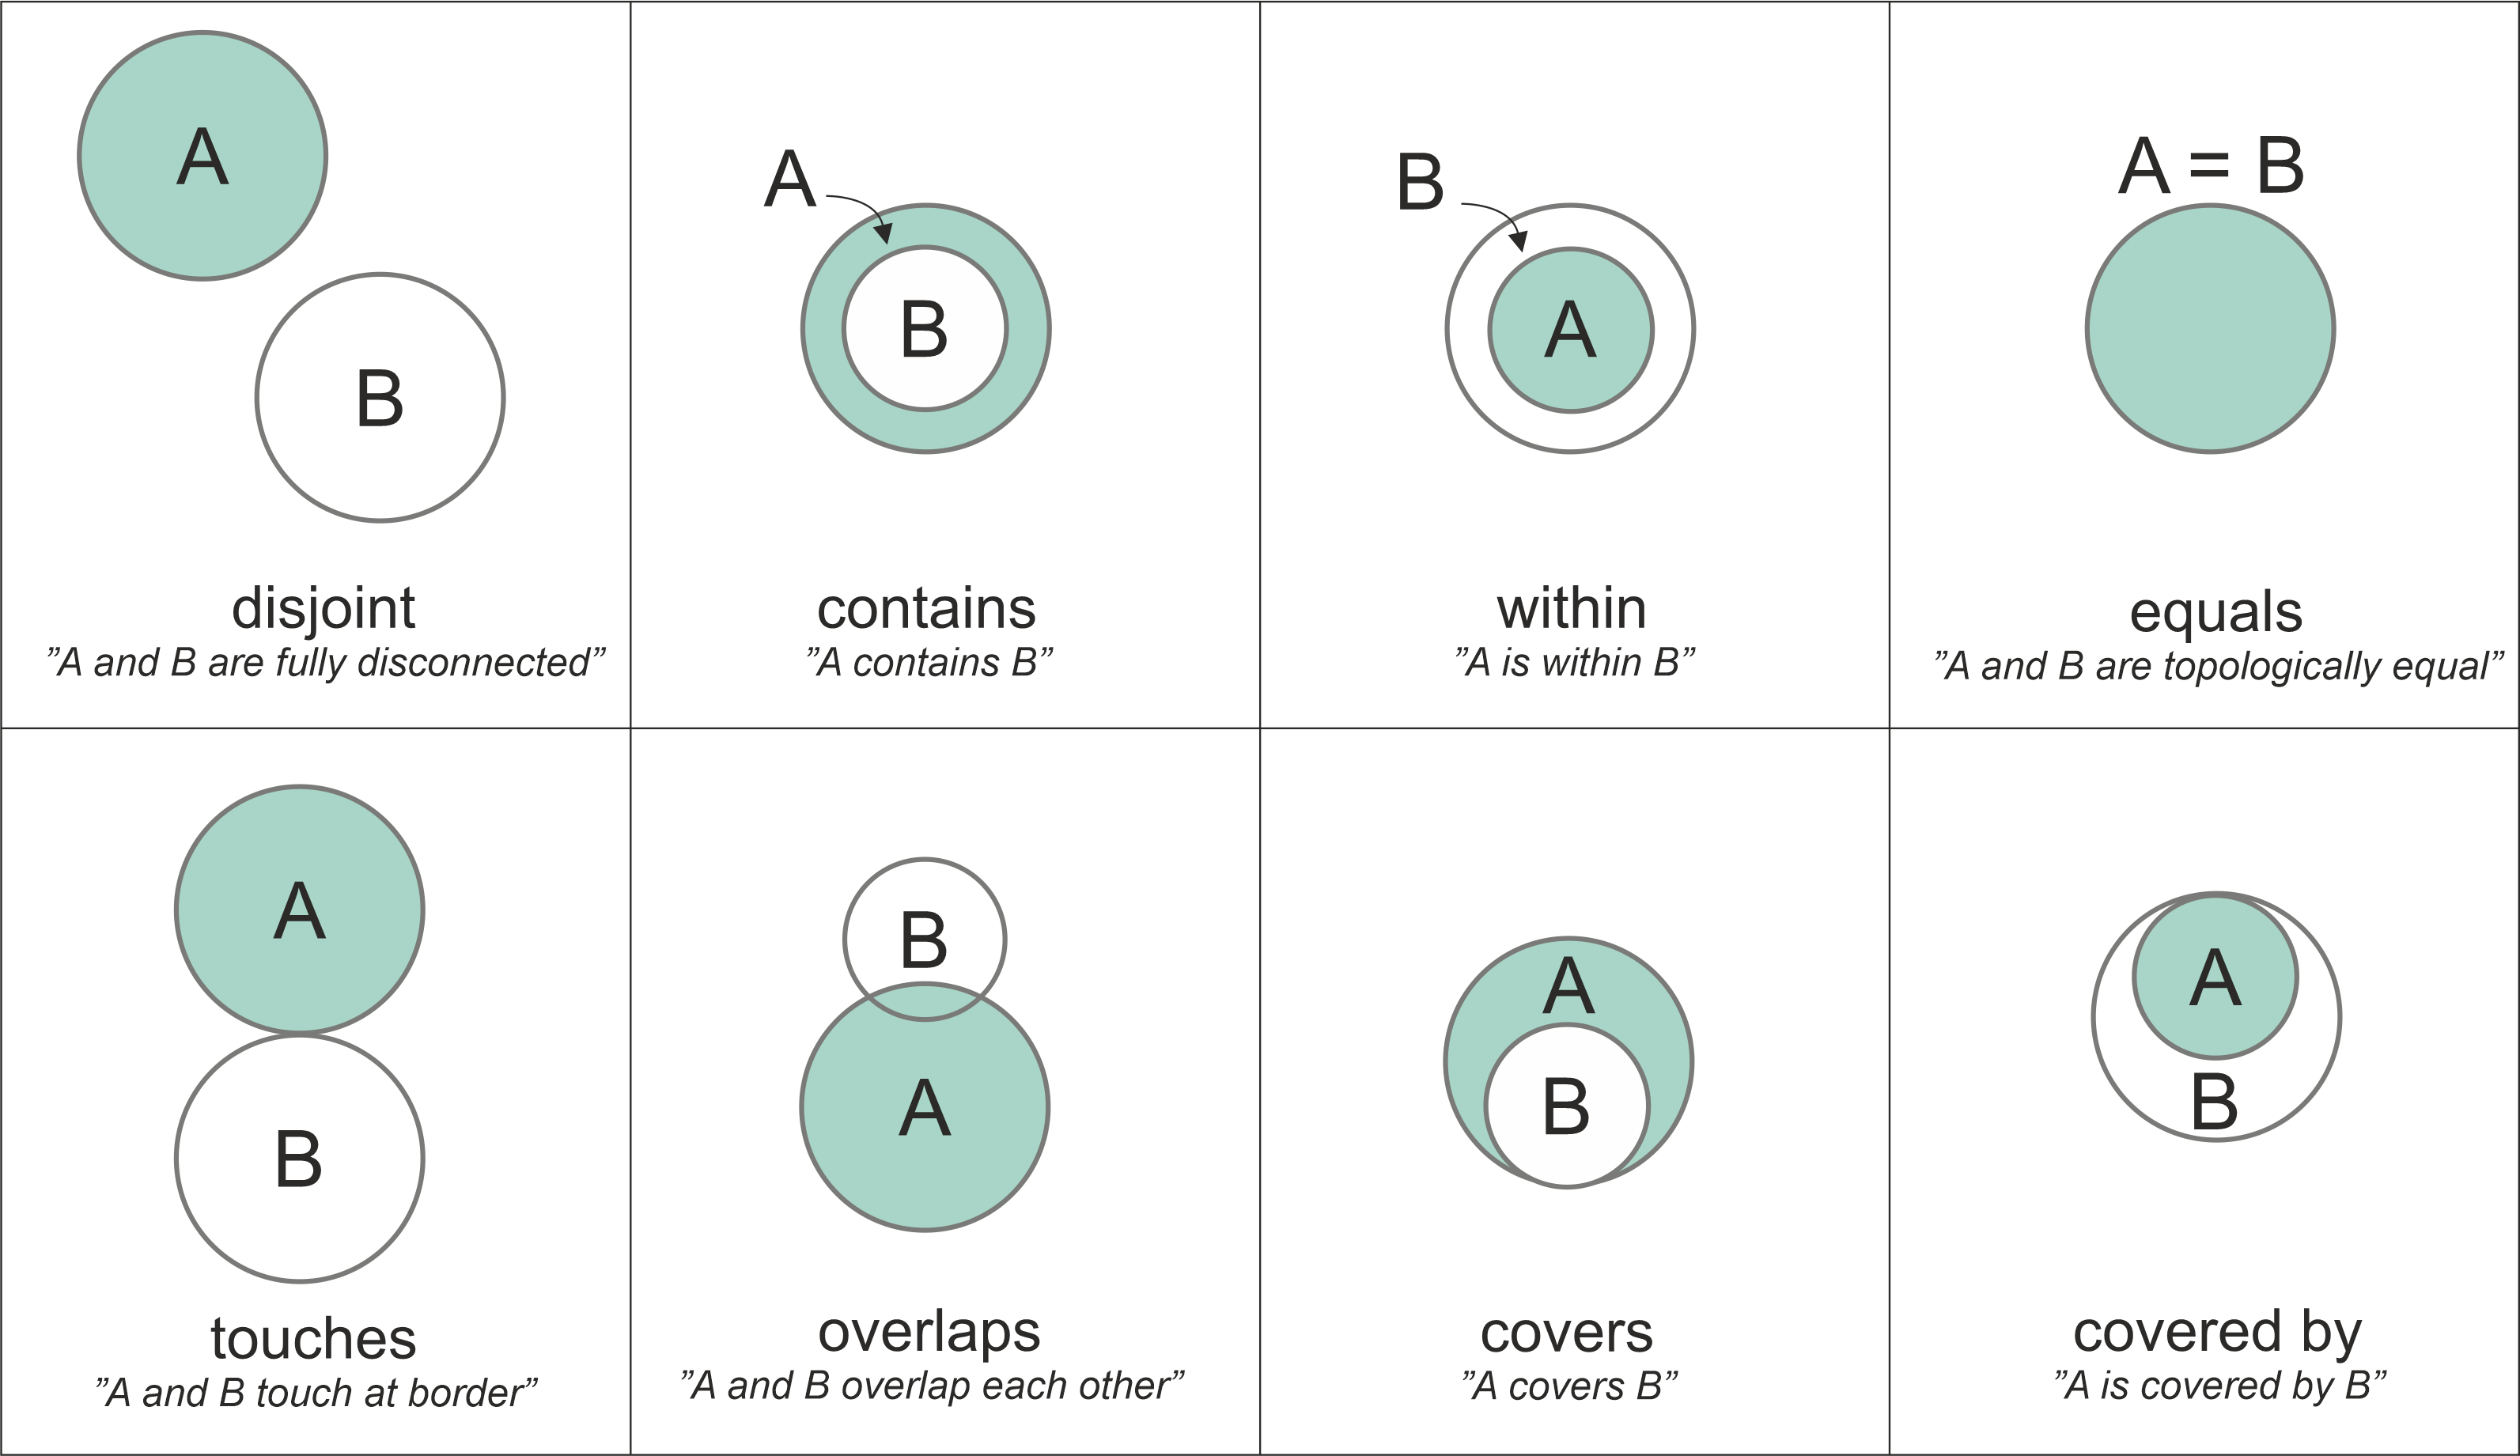

Nem todas as relações são possíveis entre todos os tipos de geometrias: um ponto nunca poderá conter uma linha ou um polígono, assim como uma linha nunca poderá conter um polígono etc.

De todo modo, as mais comuns são: *contains*/*within*, *intersects* e *disjoint*.

## Pontos e polígonos

Para começarmos com um caso mais simples, vamos contar quantos equipamentos culturais existem por distrito. Para isso, precisamos adicionar uma coluna de distrito na tabela de equipamentos culturais.

In [ ]:
distritos_gdf.nunique()

## Tipos de join em conjuntos de dados

Além do predicado geométrico, precisamos pensar também no tipo de junção baseado na teoria dos conjuntos.

Existem 4 tipos principais de join, com 3 sendo aceitos na função `sjoin`:

![types-of-joins[1].png](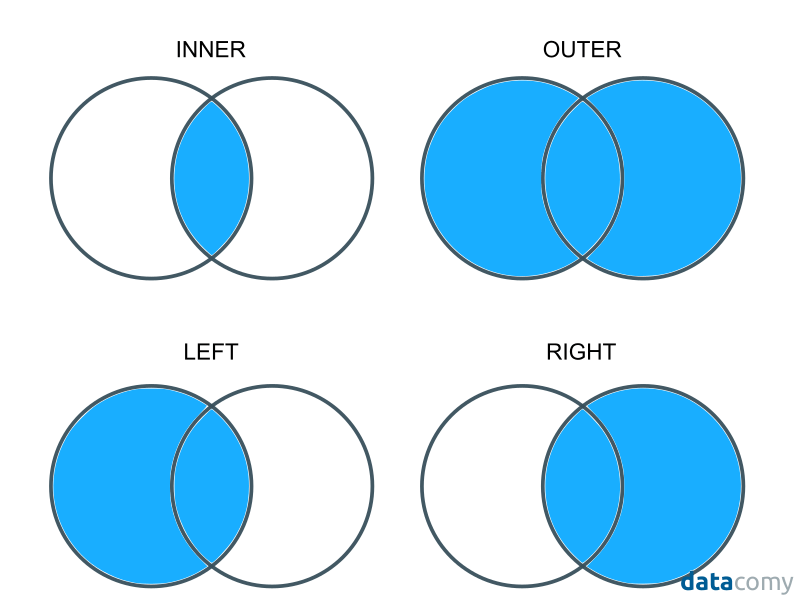)

## Spatial join entre distritos e equipamentos culturais

In [ ]:
keep_dist_cols = ['cd_identificador_distrito', 'geometry']
equip_cultura_dist_gdf = equip_cultura_gdf.sjoin(distritos_gdf[keep_dist_cols],
                                                 predicate='intersects',
                                                 how='inner')

equip_cultura_dist_gdf

## Contando a quantidade de equipamentos por distrito

In [ ]:
dist_equips_cult = (equip_cultura_dist_gdf
                    .groupby('cd_identificador_distrito')
                    .size()
                    .reset_index(name='count'))
dist_equips_cult

**Calma lá! O que foi tudo isso?**

In [ ]:
equip_cultura_dist_gdf.groupby('cd_identificador_distrito')

In [ ]:
equip_cultura_dist_gdf.groupby('cd_identificador_distrito').size()

In [ ]:
agregacoes = {'cd_identificador': 'count', 'nm_tipo_equipamento': pd.Series.mode}
equip_cultura_dist_gdf.groupby('cd_identificador_distrito').agg(agregacoes)

In [ ]:
equip_cultura_dist_gdf.groupby('cd_identificador_distrito').size().reset_index(name='count')

In [ ]:
dist_equips_cult

## Adicionando coluna na tabela de distritos

In [ ]:
distritos_gdf.merge(dist_equips_cult, on='cd_identificador_distrito')

In [ ]:
distritos_gdf.merge(dist_equips_cult, on='cd_identificador_distrito', how='left')

In [ ]:
distritos_gdf = distritos_gdf.merge(dist_equips_cult, on='cd_identificador_distrito', how='left')
distritos_gdf

In [ ]:
distritos_gdf.fillna(0, inplace=True)
distritos_gdf

In [ ]:
distritos_gdf.rename(columns={'count': 'qtd_equip_cult'}, inplace=True)
distritos_gdf

# Visualizando informações geográficas - mapas estáticos

https://matplotlib.org/stable/gallery/color/colormap_reference.html

## Começando com um mapa simples

In [ ]:
distritos_gdf.plot(column='qtd_equip_cult',
                        scheme='quantiles',
                        k=5,
                        cmap='Purples',
                        edgecolor='mediumpurple',
                        legend=True,
                        figsize=(10, 10))
plt.show()

In [ ]:
ax = distritos_gdf.plot(column='qtd_equip_cult',
                        scheme='quantiles',
                        k=5,
                        cmap='Purples',
                        edgecolor='mediumpurple',
                        legend=True,
                        figsize=(10, 10))

ax.set_title('Distribuição de Equipamentos Culturais por Distrito - São Paulo', fontsize=15)

plt.show()

## Adicionando mais de uma camada

In [ ]:
ax = distritos_gdf.plot(column='qtd_equip_cult',
                        scheme='quantiles',
                        k=5,
                        cmap='Purples',
                        edgecolor='mediumpurple',
                        legend=True,
                        figsize=(10, 10))

# Adicionando a camada de pontos
equip_cultura_gdf.plot(ax=ax, color='orange', markersize=5, alpha=0.7)

ax.set_title('Distribuição de Equipamentos Culturais por Distrito - São Paulo', fontsize=15)
plt.show()

In [ ]:
# Criando o plot base com a legenda coroplética
ax = distritos_gdf.plot(column='qtd_equip_cult',
                        scheme='quantiles',
                        k=5,
                        cmap='Purples',
                        edgecolor='mediumpurple',
                        legend=True,
                        figsize=(10, 10),
                        legend_kwds={'loc': 'upper left', 'title': 'Qtd. Equipamentos'})

# Aplicando o hachurado nos distritos com zero equipamentos
distritos_gdf[distritos_gdf['qtd_equip_cult'] == 0].plot(ax=ax,
                                                        facecolor='none',
                                                        edgecolor='mediumpurple',
                                                        hatch='///')

# Adicionando a camada de pontos
equip_cultura_gdf.plot(ax=ax, color='orange', markersize=5, alpha=0.7)

# Criando o patch para o hachurado
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='mediumpurple', hatch='///', label='Sem equipamentos')

# Recuperando os handles e labels da legenda coroplética original
# Precisamos acessar o objeto legend criado pelo GeoPandas
leg = ax.get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

# Adicionando o novo patch à lista existente e recriando a legenda
ax.legend(handles=[hatch_patch] + list(handles),
          labels=['Sem equipamentos'] + labels,
          loc='lower right',
          title='Qtd. de equipamentos culturais')

ax.set_title('Distribuição de Equipamentos Culturais por Distrito - São Paulo', fontsize=15)
plt.show()

In [ ]:
# Criando o plot base com a legenda coroplética
ax = distritos_gdf.plot(column='qtd_equip_cult',
                        scheme='quantiles',
                        k=5,
                        cmap='Purples',
                        edgecolor='mediumpurple',
                        legend=True,
                        figsize=(10, 10),
                        legend_kwds={'loc': 'upper left', 'title': 'Qtd. Equipamentos'})

# Aplicando o hachurado nos distritos com zero equipamentos
distritos_gdf[distritos_gdf['qtd_equip_cult'] == 0].plot(ax=ax,
                                                        facecolor='none',
                                                        edgecolor='mediumpurple',
                                                        hatch='///')

# Adicionando a camada de pontos
equip_cultura_gdf.plot(ax=ax, color='orange', markersize=5, alpha=0.7)

# Criando o patch para o hachurado
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='mediumpurple', hatch='///', label='Sem equipamentos')

# Recuperando os handles e labels da legenda coroplética original
# Precisamos acessar o objeto legend criado pelo GeoPandas
leg = ax.get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

# Adicionando o novo patch à lista existente e recriando a legenda
ax.legend(handles=[hatch_patch] + list(handles),
          labels=['Sem equipamentos'] + labels,
          loc='lower right',
          title='Qtd. de equipamentos culturais')

ax.set_title('Distribuição de Equipamentos Culturais por Distrito - São Paulo', fontsize=15)
plt.show()

In [ ]:
!pip install matplotlib-map-utils

## Mapa final com vários elementos

In [ ]:
from matplotlib_map_utils.core.north_arrow import north_arrow
from matplotlib_map_utils.core.scale_bar import scale_bar
from matplotlib.lines import Line2D

# Criando o plot base com a legenda coroplética
ax = distritos_gdf.plot(column='qtd_equip_cult',
                        scheme='quantiles',
                        k=5,
                        cmap='Purples',
                        edgecolor='mediumpurple',
                        legend=True,
                        figsize=(10, 10),
                        legend_kwds={'loc': 'upper left', 'title': 'Qtd. Equipamentos'})

# Aplicando o hachurado nos distritos com zero equipamentos
distritos_gdf[distritos_gdf['qtd_equip_cult'] == 0].plot(ax=ax,
                                                        facecolor='none',
                                                        edgecolor='mediumpurple',
                                                        hatch='///')

# Adicionando a camada de pontos
equip_cultura_gdf.plot(ax=ax, color='orange', markersize=5, alpha=0.7)

# Criando os patches e handles personalizados para a legenda
hatch_patch = mpatches.Patch(facecolor='none', edgecolor='mediumpurple', hatch='///', label='Sem equipamentos')
point_handle = Line2D([0], [0], marker='o', color='w', label='Equipamento cultural',
                      markerfacecolor='orange', markersize=8)

# Recuperando os handles e labels da legenda coroplética original
leg = ax.get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

# Unificando todos os itens na legenda final
ax.legend(handles=[hatch_patch] + list(handles) + [point_handle],
          labels=['Sem equipamentos'] + labels + ['Equipamento cultural'],
          loc='lower right',
          title='Qtd. de equipamentos culturais')

# Adicionando a Régua de Escala
scale_bar(
    ax, location="lower left", style="boxes", bar={"projection": distritos_gdf.crs, "unit": "km"}
)

# Adicionando o Indicador de Norte
north_arrow(
    ax, location="center right", rotation={"crs": distritos_gdf.crs, "reference": "center"}
)

# Adicionando anotação do CRS em duas linhas acima da legenda
crs_name = distritos_gdf.crs.name
ax.annotate(f"Sist. Ref. Coordenadas:\n{crs_name}",
            xy=(0.98, 0.23), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')

ax.set_title('Distribuição de Equipamentos Culturais por Distrito - São Paulo', fontsize=15)
plt.show()

# Agregando (mais) informações

# Polígonos e Polígonos

E se quisermos mais do que contagens? Por exempo, e se quisermos calcular o percentual de uma determinada área em outra?

## Percentual de área de inundação por distritos

In [ ]:
ax = distritos_gdf.plot(facecolor='none', edgecolor='grey', figsize=(12, 12))
area_inund_gdf.plot(ax=ax)


https://geopandas.org/en/stable/docs/user_guide/set_operations.html

![overlay_operations[1].png](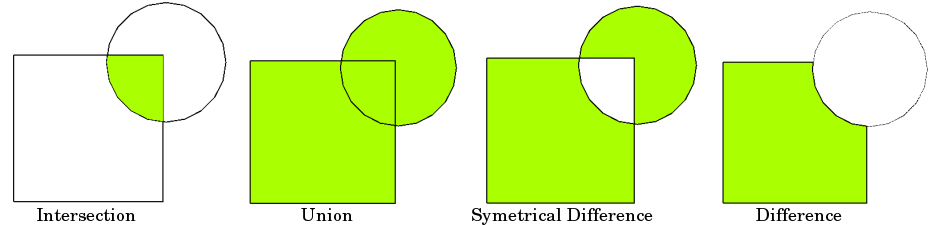)

## Calculando interseções

In [ ]:
distritos_gdf.crs

In [ ]:
area_inund_gdf.crs

In [ ]:
inter_inund_dist = distritos_gdf.overlay(area_inund_gdf, how='intersection')
inter_inund_dist

In [ ]:
area_inund_gdf[area_inund_gdf['cd_identificador_area_inundavel']==183]

In [ ]:
area_inund_gdf[area_inund_gdf['cd_identificador_area_inundavel']==183].plot()

In [ ]:
inter_inund_dist[inter_inund_dist['cd_identificador_area_inundavel']==183]

In [ ]:
ax = distritos_gdf.plot(facecolor='none', edgecolor='grey', figsize=(12, 12))
(
    inter_inund_dist[inter_inund_dist['cd_identificador_area_inundavel']==183]
    .plot(ax=ax, column='nm_distrito_municipal')
)
plt.show()

## Calculando as áreas

In [ ]:
inter_inund_dist.area

In [ ]:
inter_inund_dist['area'] = inter_inund_dist.area

inter_inund_dist

In [ ]:
area_inund_dist = (
    inter_inund_dist
    .groupby('cd_identificador_distrito')
    .agg({'area': 'sum'})
    .reset_index()
)
area_inund_dist

$$ pct\_inund = 100\times\frac{area\_inund}{area\_dist} $$

In [ ]:
area_inund_dist.rename(columns={'area': 'area_inund'}, inplace=True)
area_inund_dist

In [ ]:
distritos_gdf['area_dist'] = distritos_gdf.area
distritos_gdf

In [ ]:
(
    distritos_gdf
    .merge(area_inund_dist,
           on='cd_identificador_distrito',
           how='left')
)

In [ ]:
distritos_gdf = distritos_gdf.merge(area_inund_dist,
                                    on='cd_identificador_distrito',
                                    how='left')

distritos_gdf['area_inund'].fillna(0, inplace=True)
distritos_gdf

In [ ]:
distritos_gdf['pct_inund'] = distritos_gdf['area_inund']/distritos_gdf['area_dist']
distritos_gdf

# Visualizando (mais) informações

## Visualizando as áreas com um gráfico de barras

In [ ]:
import plotly.express as px

# Criando o gráfico de barras vertical
fig = px.bar(distritos_gdf.sort_values('pct_inund', ascending=True),
             y='nm_distrito_municipal',
             x='pct_inund',
             title='Percentual de Área Inundável por Distrito - São Paulo',
             labels={'nm_distrito_municipal': 'Distrito', 'pct_inund': 'Percentual de Inundação'})

fig.update_layout(
    xaxis= dict(
        tickformat= '.1%'
        )
)

fig.show()

## Visualizando com um mapa interativo

In [ ]:
import folium
from folium.plugins import Fullscreen

plot_gdf = distritos_gdf.copy()
plot_gdf = plot_gdf[['geometry','nm_distrito_municipal', 'pct_inund']]
plot_gdf.rename(columns={'pct_inund': 'Percentual de área inundável',
                         'nm_distrito_municipal': 'Distrito'},
                inplace=True)

# Criando o mapa base com a camada de distritos (coroplético)
# Definindo explicitamente o mapa base inicial
m = plot_gdf.explore(
    column='Percentual de área inundável',
    cmap='Blues',
    name='Percentual de Inundação (Distritos)',
    tooltip=['Distrito', 'Percentual de área inundável'],
    popup=True,
    style_kwds={'fillOpacity': 0.6}
)

# Adicionando a camada base do Google Satellite
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google',
    name='Google Satellite',
    overlay=False,
    control=True
).add_to(m)

# Adicionando a camada base do Google Satellite
folium.TileLayer(
    tiles='Cartodb Positron',
    overlay=False,
    control=True
).add_to(m)

# Adicionando a camada das áreas de interseção de inundação
inter_inund_dist_plot = inter_inund_dist.copy()
inter_inund_dist_plot = inter_inund_dist_plot[['geometry', 'cd_identificador_area_inundavel', 'nm_distrito_municipal']]
inter_inund_dist_plot.rename(columns={'nm_distrito_municipal': 'Distrito'}, inplace=True)

inter_inund_dist_plot.explore(
    m=m,
    color='lightskyblue',
    name='Manchas de Inundação',
    style_kwds={'fillOpacity': 0.2, 'opacity': 0.8}
)

# Adicionando controle de camadas e tela cheia
folium.LayerControl().add_to(m)
Fullscreen().add_to(m)

m

# Salvando as informações

Salvando o mapa interativo em html

In [ ]:
m.save('mapa inundação.html')

Salvando os dados como um arquivo

In [ ]:
distritos_gdf.to_file('area_inundação_distritos.geojson')